# Modélisation - LSTM vs Random Forest

## Objectif

1. **Random Forest** - modèle baseline (simple, rapide)
2. **LSTM** - modèle principal (deep learning, séries temporelles)

## Plan de ce notebook

1. Charger les données avec features
2. Définir les features (X) et la target (Y)
3. Séparer train / test (split chronologique)
4. Entraîner le Random Forest
5. Entraîner le LSTM
6. Comparer les résultats

## Métriques d'évaluation

- **RMSE** (Root Mean Square Error) → erreur moyenne en mètres
- **MAE** (Mean Absolute Error) → erreur absolue moyenne en mètres
- **R²** (coefficient de détermination) → entre 0 et 1, plus c'est proche de 1 mieux c'est

## Étape 1 : Charger les données et définir X et Y

**Target (Y)** : Depth_to_Groundwater_P24 - le niveau d'eau qu'on veut prédire

**Features (X)** : toutes les autres colonnes numériques sauf la Date 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Charger le dataset avec features
df = pd.read_csv('../data/processed/Nappe_Petrignano_features_created.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Définir la target
TARGET = 'Depth_to_Groundwater_P24'

# Définir les features (tout sauf Date et Target)
FEATURES = [col for col in df.columns if col not in ['Date', TARGET]]

print(f"\nTarget : {TARGET}")
print(f"\nFeatures ({len(FEATURES)}) :")
for f in FEATURES:
    print(f"  → {f}")

Dataset chargé : 4169 lignes, 24 colonnes

Target : Depth_to_Groundwater_P24

Features (22) :
  → Rainfall_Bastia_Umbra
  → Temperature_Bastia_Umbra
  → Temperature_Petrignano
  → Volume_C10_Petrignano
  → Hydrometry_Fiume_Chiascio_Petrignano
  → Mois_sin
  → Mois_cos
  → Niveau_P24_lag7
  → Niveau_P24_lag14
  → Niveau_P24_lag30
  → Pluie_lag7
  → Pluie_lag14
  → Pluie_lag30
  → Pluie_moy7
  → Pluie_moy14
  → Pluie_moy30
  → Pompage_moy7
  → Pompage_moy14
  → Pompage_moy30
  → Niveau_P24_moy7
  → Pluie_cum30
  → Pompage_cum30


## Étape 2 : Séparation Train / Test

- **Train (80%)** -> le modèle apprend sur ces données
- **Test (20%)** -> on évalue le modèle sur des données qu'il n'a jamais vues  

les données ne seront pas mélangés. On coupe chronologiquement : les premières années pour l'entraînement, les dernières années pour le test.


In [2]:
# Séparer features (X) et target (Y)
X = df[FEATURES]
y = df[TARGET]
dates = df['Date']

# Split chronologique : 80% train, 20% test
split_index = int(len(df) * 0.8)
split_date = dates.iloc[split_index]

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]
dates_train = dates.iloc[:split_index]
dates_test  = dates.iloc[split_index:]

print("=== Séparation Train / Test ===\n")
print(f"Date de coupure : {split_date.date()}\n")
print(f"Train : {len(X_train)} lignes ({len(X_train)/len(df)*100:.0f}%)")
print(f"  → du {dates_train.iloc[0].date()} au {dates_train.iloc[-1].date()}")
print(f"\nTest  : {len(X_test)} lignes ({len(X_test)/len(df)*100:.0f}%)")
print(f"  → du {dates_test.iloc[0].date()} au {dates_test.iloc[-1].date()}")

=== Séparation Train / Test ===

Date de coupure : 2018-03-20

Train : 3335 lignes (80%)
  → du 2009-01-31 au 2018-03-19

Test  : 834 lignes (20%)
  → du 2018-03-20 au 2020-06-30


## Étape 3 : Entraînement du Random Forest (baseline) (sans optimisation)

In [3]:
#entrainement sans optimisation
from sklearn.ensemble import RandomForestRegressor

# Créer le modèle Random Forest
# n_estimators = nombre d'arbres dans la forêt
# random_state = graine aléatoire (pour que les résultats soient reproductibles)
rf_model = RandomForestRegressor(
    n_estimators=100,    # 100 arbres, bon équilibre performance/temps
    max_depth=15,        # profondeur max de chaque arbre, le nombre maximum de niveaux de coupures qu'un arbre peut faire.
    random_state=42      # résultat reproductible
)

# Entraîner le modèle
# Le modèle apprend la relation entre X_train (features) et y_train (target)
rf_model.fit(X_train, y_train)

print("=== Random Forest entraîné ===\n")
print(f"Nombre d'arbres : {rf_model.n_estimators}")
print(f"Profondeur max  : {rf_model.max_depth}")
print(f"Features utilisées : {len(FEATURES)}")

=== Random Forest entraîné ===

Nombre d'arbres : 100
Profondeur max  : 15
Features utilisées : 22


## Étape 4 : Évaluation (sans optimisation)

On va mesurer la qualité du modèle sur les données de **test**  
(2018-2020) - des données qu'il n'a jamais vues.

In [5]:
# Prédictions sur le test
y_pred_rf = rf_model.predict(X_test)

# Calculer les métriques
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Résultats Random Forest (sur données test) ===\n")
print(f"  RMSE : {rmse_rf:.4f} m")
print(f"  MAE  : {mae_rf:.4f} m")
print(f"  R²   : {r2_rf:.4f}")

if r2_rf > 0.85:
    print(f"\n  → R² > 0.85 : objectif atteint !")
else:
    print(f"\n  → R² < 0.85 : le LSTM devra faire mieux")

=== Résultats Random Forest (sur données test) ===

  RMSE : 0.2004 m
  MAE  : 0.1628 m
  R²   : 0.9456

  → R² > 0.85 : objectif atteint !


## Étape 5 : Entraînement du Random Forest (baseline) (Avec optimisation)
On teste plusieurs combinaisons d'hyperparamètres pour trouver le meilleur modèle.

In [6]:
#entrainement avec optimisation

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Définir les combinaisons à tester
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

# TimeSeriesSplit : validation croisée adaptée aux séries temporelles
# (pas de mélange aléatoire, respecte l'ordre chronologique)
tscv = TimeSeriesSplit(n_splits=3)

# Créer et lancer la recherche
rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,    # utiliser tous les cœurs du processeur
    verbose=1
)

print("=== Recherche des meilleurs hyperparamètres ===")
print(f"Combinaisons à tester : {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])}")
print("Patience, ça peut prendre 1-2 minutes...\n")

grid_search.fit(X_train, y_train)

# Afficher les résultats
print(f"\n=== Meilleurs hyperparamètres trouvés ===\n")
print(f"  n_estimators     : {grid_search.best_params_['n_estimators']}")
print(f"  max_depth        : {grid_search.best_params_['max_depth']}")
print(f"  min_samples_split: {grid_search.best_params_['min_samples_split']}")
print(f"\n  Meilleur R² (validation) : {grid_search.best_score_:.4f}")

# Garder le meilleur modèle
rf_model = grid_search.best_estimator_

=== Recherche des meilleurs hyperparamètres ===
Combinaisons à tester : 36
Patience, ça peut prendre 1-2 minutes...

Fitting 3 folds for each of 36 candidates, totalling 108 fits

=== Meilleurs hyperparamètres trouvés ===

  n_estimators     : 100
  max_depth        : 10
  min_samples_split: 2

  Meilleur R² (validation) : 0.3790


## Étape 6 : Évaluation (avec optimisation)


In [7]:
# Prédictions avec le modèle optimisé
y_pred_rf = rf_model.predict(X_test)

# Calculer les métriques
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Résultats Random Forest OPTIMISÉ (sur données test) ===\n")
print(f"  RMSE : {rmse_rf:.4f} m")
print(f"  MAE  : {mae_rf:.4f} m")
print(f"  R²   : {r2_rf:.4f}")

print(f"\n  → Rappel : R² avant optimisation = 0.9456")
if r2_rf > 0.9456:
    print(f"  → Amélioration de {(r2_rf - 0.9456)*100:.2f} points")
else:
    print(f"  → Légère baisse, le modèle initial était déjà bon")

=== Résultats Random Forest OPTIMISÉ (sur données test) ===

  RMSE : 0.1979 m
  MAE  : 0.1606 m
  R²   : 0.9469

  → Rappel : R² avant optimisation = 0.9456
  → Amélioration de 0.13 points


## Étape 7 : Visualisation des prédictions Random Forest

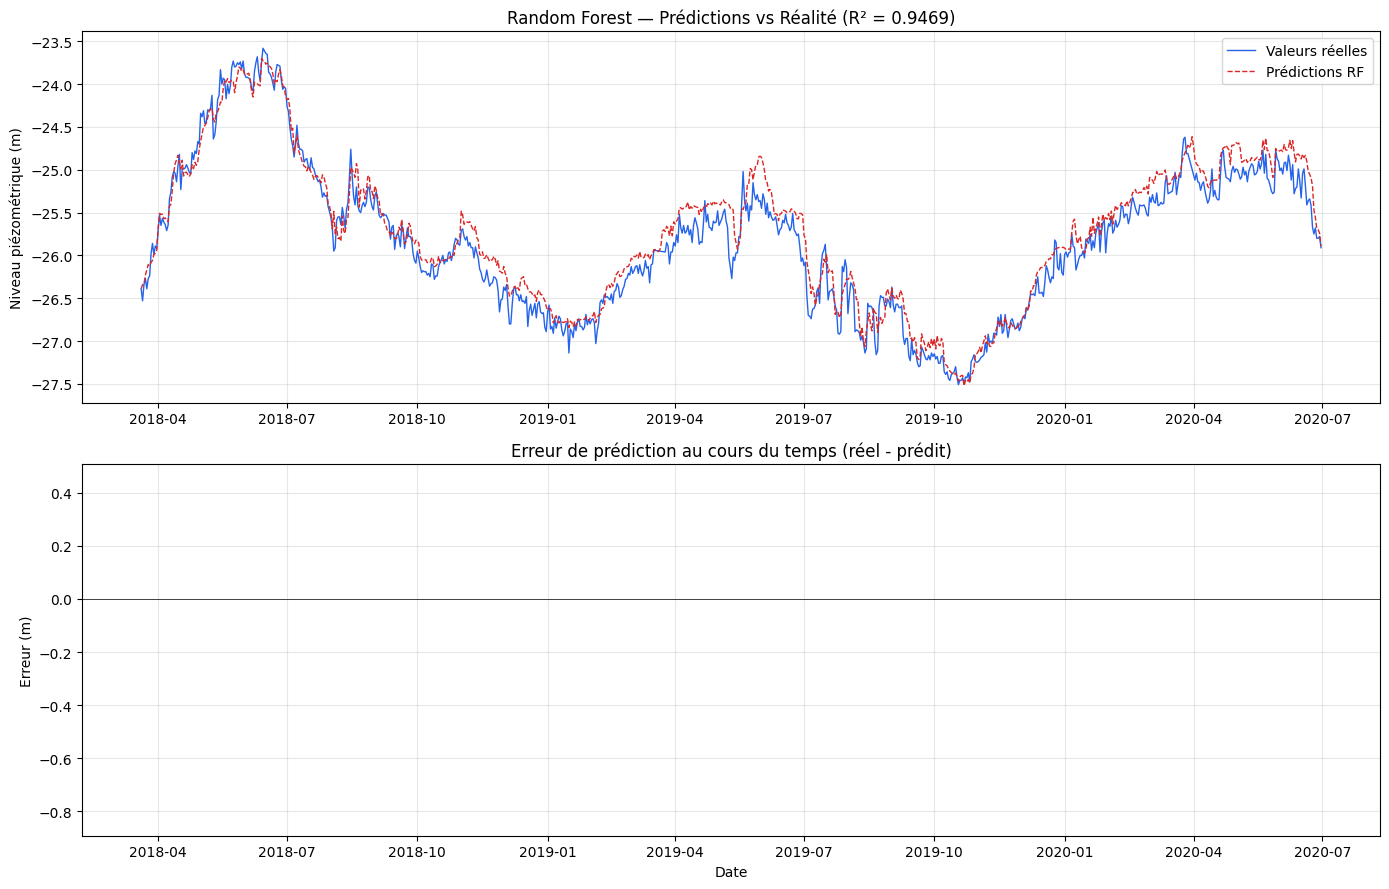

→ Figure sauvegardée dans data/processed/


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Graphique 1 : valeurs réelles vs prédites
axes[0].plot(dates_test.values, y_test.values, 
             color='#2563EB', linewidth=1, label='Valeurs réelles')
axes[0].plot(dates_test.values, y_pred_rf, 
             color='#DC2626', linewidth=1, linestyle='--', label='Prédictions RF')
axes[0].set_ylabel('Niveau piézométrique (m)')
axes[0].set_title(f'Random Forest — Prédictions vs Réalité (R² = {r2_rf:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : erreur au cours du temps
erreur = y_test.values - y_pred_rf
axes[1].bar(dates_test.values, erreur, color='#F59E0B', alpha=0.6, width=2)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_ylabel('Erreur (m)')
axes[1].set_xlabel('Date')
axes[1].set_title('Erreur de prédiction au cours du temps (réel - prédit)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/11_fig_randomforest_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée dans data/processed/")

## Étape 8 : Importance des features (Random Forest)

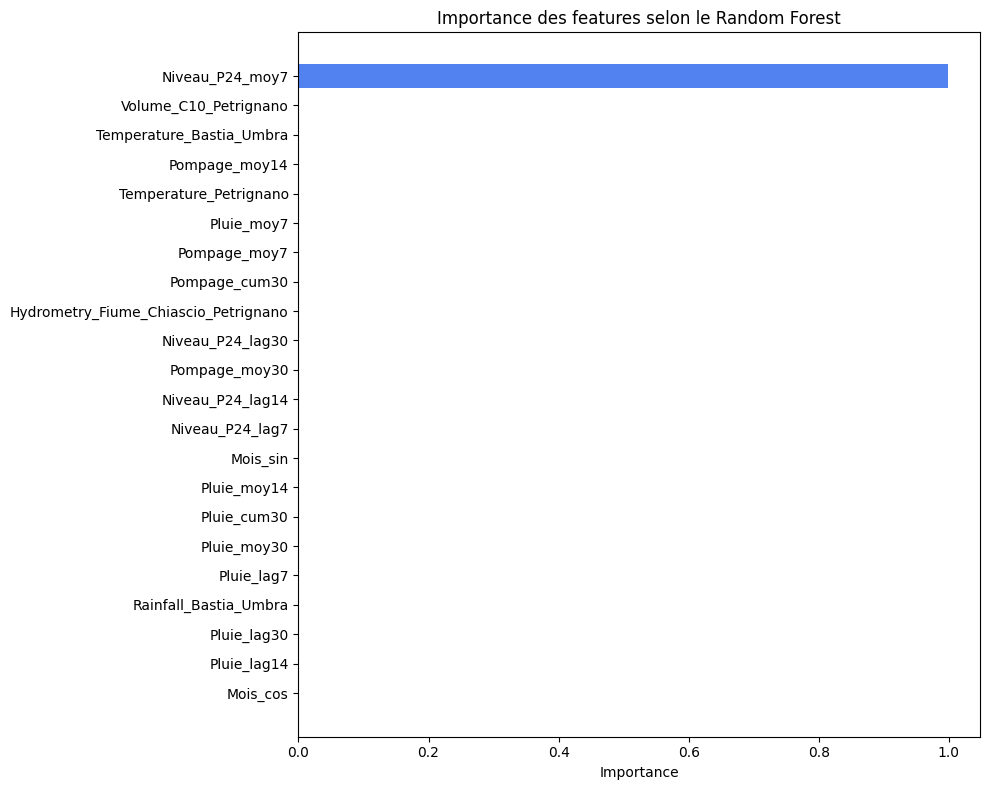


=== Top 5 des features les plus importantes ===

  Temperature_Petrignano         → 0.0001
  Pompage_moy14                  → 0.0001
  Temperature_Bastia_Umbra       → 0.0002
  Volume_C10_Petrignano          → 0.0005
  Niveau_P24_moy7                → 0.9981


In [9]:
# Récupérer l'importance des features
importances = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Visualiser
plt.figure(figsize=(10, 8))
plt.barh(importances['Feature'], importances['Importance'], color='#2563EB', alpha=0.8)
plt.xlabel('Importance')
plt.title('Importance des features selon le Random Forest')
plt.tight_layout()
plt.savefig('../data/processed/12_fig_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5
print("\n=== Top 5 des features les plus importantes ===\n")
top5 = importances.tail(5)
for _, row in top5.iterrows():
    print(f"  {row['Feature']:30s} → {row['Importance']:.4f}")

## Étape 9 : Préparation des données pour le LSTM

Le LSTM a besoin d'un prétraitement spécifique en 3 étapes :

1. **Sélectionner les features** - on utilise les colonnes brutes (pas les lags, le LSTM lit les séquences lui-même)
2. **Normaliser** entre 0 et 1 - obligatoire pour le LSTM
3. **Créer les séquences 3D** - découper en fenêtres glissantes

In [10]:
from sklearn.preprocessing import MinMaxScaler

# === Étape 1 : Sélectionner les features pour le LSTM ===
# On prend les colonnes brutes seulement (pas les lags ni les rolling)
FEATURES_LSTM = [
    'Rainfall_Bastia_Umbra',
    'Temperature_Bastia_Umbra',
    'Temperature_Petrignano',
    'Volume_C10_Petrignano',
    'Hydrometry_Fiume_Chiascio_Petrignano',
    'Mois_sin',
    'Mois_cos'
]

print(f"Features pour le LSTM ({len(FEATURES_LSTM)}) :")
for f in FEATURES_LSTM:
    print(f"  → {f}")

# Préparer les données
data_lstm = df[FEATURES_LSTM + [TARGET]].copy()

print(f"\nShape des données LSTM : {data_lstm.shape}")
# data_lstm.sort_values(by='Depth_to_Groundwater_P24',ascending=False)

Features pour le LSTM (7) :
  → Rainfall_Bastia_Umbra
  → Temperature_Bastia_Umbra
  → Temperature_Petrignano
  → Volume_C10_Petrignano
  → Hydrometry_Fiume_Chiascio_Petrignano
  → Mois_sin
  → Mois_cos

Shape des données LSTM : (4169, 8)


## Étape 10 : Normalisation des données (MinMaxScaler)

On transforme **chaque colonne** pour que ses valeurs soient entre 0 et 1 :
- La valeur minimale devient 0
- La valeur maximale devient 1
- Toutes les autres sont proportionnellement entre les deux

In [11]:
# === Étape 2 : Normalisation ===

# Séparer train et test AVANT de normaliser
split_index_lstm = int(len(data_lstm) * 0.8)

train_data = data_lstm.iloc[:split_index_lstm].values
test_data  = data_lstm.iloc[split_index_lstm:].values


print(f"Train : {train_data.shape[0]} lignes")
print(f"Test  : {test_data.shape[0]} lignes")

# Créer le scaler et l'ajuster UNIQUEMENT sur le train
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

# Vérifier
print(f"\nAvant normalisation (train) :")
print(f"  Min : {train_data.min(axis=0).round(2)}")
print(f"  Max : {train_data.max(axis=0).round(2)}")

# print(f"\nAvant normalisation (test) :")
# print(f"  Min : {test_data.min(axis=0).round(2)}")
# print(f"  Max : {test_data.max(axis=0).round(2)}")

print(f"\nAprès normalisation (train) :")
print(f"  Min : {train_scaled.min(axis=0).round(2)}")
print(f"  Max : {train_scaled.max(axis=0).round(2)}")

# print(f"\nAprès normalisation (test) :")
# print(f"  Min : {test_scaled.min(axis=0).round(2)}")
# print(f"  Max : {test_scaled.max(axis=0).round(2)}")

Train : 3335 lignes
Test  : 834 lignes

Avant normalisation (train) :
  Min : [ 0.000000e+00 -3.700000e+00 -4.200000e+00 -4.189018e+04  0.000000e+00
 -1.000000e+00 -1.000000e+00 -3.447000e+01]
  Max : [ 67.3   33.    31.1    0.     4.1    1.     1.   -19.66]

Après normalisation (train) :
  Min : [0. 0. 0. 0. 0. 0. 0. 0.]
  Max : [1. 1. 1. 1. 1. 1. 1. 1.]


## Étape 11 : Création des séquences 3D

On découpe les données en **fenêtres glissantes** de 30 jours.  
Chaque fenêtre = une séquence que le LSTM lira jour par jour.

### Exemple avec une fenêtre de 30 jours :

- Séquence 1 : jours 1 à 30 → prédit jour 31
- Séquence 2 : jours 2 à 31 → prédit jour 32
- Séquence 3 : jours 3 à 32 → prédit jour 33
- ...

In [12]:
# === Étape 3 : Créer les séquences glissantes ===

WINDOW_SIZE = 30  # nombre de jours dans chaque séquence

def create_sequences(data, window_size):
    """
    Découpe les données en séquences glissantes.
    
    data : tableau normalisé (lignes × colonnes)
    window_size : nombre de jours par séquence
    
    Retourne :
    X : les séquences de features (séquences × jours × features)
    y : la target à prédire pour chaque séquence
    """
    X, y = [], []
    
    # La target (niveau P24) est la DERNIÈRE colonne
    for i in range(window_size, len(data)):
        # Les 30 jours précédents = la séquence (TOUTES les colonnes sauf la dernière)
        sequence = data[i - window_size:i, :-1]  
        # Le jour suivant = la target (dernière colonne uniquement)
        target = data[i, -1]                      
        
        X.append(sequence)
        y.append(target)
    
    return np.array(X), np.array(y)

# Créer les séquences pour le train et le test
X_train_lstm, y_train_lstm = create_sequences(train_scaled, WINDOW_SIZE)
X_test_lstm, y_test_lstm   = create_sequences(test_scaled, WINDOW_SIZE)

print(f"=== Séquences créées (fenêtre = {WINDOW_SIZE} jours) ===\n")
print(f"X_train : {X_train_lstm.shape}")
print(f"  → {X_train_lstm.shape[0]} séquences")
print(f"  → {X_train_lstm.shape[1]} jours par séquence")
print(f"  → {X_train_lstm.shape[2]} features par jour")
print(f"\ny_train : {y_train_lstm.shape}")
print(f"  → {y_train_lstm.shape[0]} valeurs à prédire")
print(f"\nX_test  : {X_test_lstm.shape}")
print(f"y_test  : {y_test_lstm.shape}")

=== Séquences créées (fenêtre = 30 jours) ===

X_train : (3305, 30, 7)
  → 3305 séquences
  → 30 jours par séquence
  → 7 features par jour

y_train : (3305,)
  → 3305 valeurs à prédire

X_test  : (804, 30, 7)
y_test  : (804,)


In [192]:
# data = data_lstm.values
# window_size = 30
# X, y = [], []
# for i in range(window_size, len(data)):
#         # Les 30 jours précédents = la séquence (TOUTES les colonnes sauf la dernière)
#         sequence = data[i - window_size:i, :-1]  
#         # Le jour suivant = la target (dernière colonne uniquement)
#         target = data[i, -1]                      
        
#         X.append(sequence) #features entre 0 -> 4138 chaque index contient séq1 : jr 1 -> jr 30 , séq 2 : jr 2 -> jr 31 .... séq(len data - win size) : jr (len data - win size) -> jr (len data) ---- séq = index, jr = tous lrs features
#         y.append(target) #targets entre 30 -> 4168 ; les 1->30 jours des features prédit la valeur du 31 jour ; les 4139->4168 jours prédit la valeur du 4169 jour
# X = np.array(X)
# y =  np.array(y)

## Étape 10 : Construction du modèle LSTM

### Hyperparamètres choisis :
- **64 neurones** : assez pour capturer les patterns, pas trop pour overfitter
- **Dropout 20%** : régularisation légère
- **Optimizer Adam** : le plus utilisé, s'adapte automatiquement
- **Loss MSE** : erreur quadratique moyenne, standard pour la régression
- **Batch size 32** : le modèle met à jour ses poids toutes les 32 séquences. LSTM lit une fenetre(séq), il effectue une une prédiction, il regroupe plusieurs fenêtres ensemble (32). Le LSTM traite les 32 fenêtres, obtient 32 prédictions, calcule une loss moyenne sur ces 32 erreurs, puis corrige les poids une seule fois. après il passe au 2éme batch, pour 3305 fenetres ça fait environ 104 batch, donc 104 correction des poids W,b
- **50 époques** : nombre de passages sur les données d'entraînement. LSTM parcourt toutes les fenetres au moins une seul fois, 104 batch. 50 époque donne 104*50 correction des poids

In [193]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# === Construire le modèle ===
model = Sequential([
    # Couche LSTM : lit les séquences et accumule la mémoire
    LSTM(64, input_shape=(WINDOW_SIZE, len(FEATURES_LSTM))),
    
    # Dropout : éteint 20% des neurones aléatoirement (anti-overfitting)
    Dropout(0.2),
    
    # Dense : transforme le résumé en une prédiction unique
    Dense(1)
])

# Compiler le modèle (définir comment il apprend)
model.compile(
    optimizer='adam',     # algorithme d'optimisation
    loss='mse'           # fonction d'erreur (Mean Squared Error)
)

# Afficher l'architecture
model.summary()

d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

## Étape 11 : Entraînement du LSTM

On lance l'entraînement sur 50 époques maximum.  
Une époque = le modèle parcourt TOUTES les séquences d'entraînement une fois. À chaque époque, il s'améliore un peu en ajustant ses 18 497 paramètres.

### Early Stopping
On utilise le mécanisme d'arrêt précoce : si le modèle ne s'améliore plus sur les données de validation pendant 10 époques consécutives, on arrête l'entraînement automatiquement.

Cela évite l'overfitting : le modèle s'arrête au moment optimal au lieu de mémoriser les données.

### Validation
On utilise 20% des données de train comme validation pour surveiller l'overfitting en temps réel.

In [194]:
# === Entraîner le LSTM ===

# Early stopping : arrêter si pas d'amélioration pendant 10 époques
early_stop = EarlyStopping(
    monitor='val_loss',    # surveiller l'erreur sur la validation
    patience=10,           # attendre 10 époques sans amélioration, 
    restore_best_weights=True  # garder les poids de la meilleure époque
)

print("=== Entraînement du LSTM ===\n")

# Lancer l'entraînement
history = model.fit(
    X_train_lstm, y_train_lstm,    # données d'entraînement
    epochs=50,                      # maximum 50 époques
    batch_size=32,                  # mise à jour toutes les 32 séquences
    validation_split=0.2,           # 20% du train pour la validation, le modèle les utilise uniquement pour vérifier s'il progresse
    callbacks=[early_stop],         # arrêt précoce
    verbose=1                       # afficher la progression
)

print(f"\n→ Entraînement terminé en {len(history.history['loss'])} époques")

=== Entraînement du LSTM ===

Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0567 - val_loss: 0.0121
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0365 - val_loss: 0.0152
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0353 - val_loss: 0.0100
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0359 - val_loss: 0.0297
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0330 - val_loss: 0.0280
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0318 - val_loss: 0.0364
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0318 - val_loss: 0.0375
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0303 - val_loss: 0.0334
Epoch 9/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0293 - val_loss: 0.0429
Epoch 10/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0290 - val_loss: 0.0392
Epoch 11/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0300 - val_loss: 0.0497
Epoch 12/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7

## Étape 12 : Courbe d'apprentissage

On trace l'évolution de l'erreur (loss) pendant l'entraînement.  
Les deux courbes (train et validation) nous montrent  
si le modèle apprend bien ou s'il overfitte.

- **Les deux baissent ensemble** → le modèle apprend bien
- **Train baisse mais validation remonte** -> overfitting
- **Les deux stagnent haut** → le modèle n'apprend pas assez

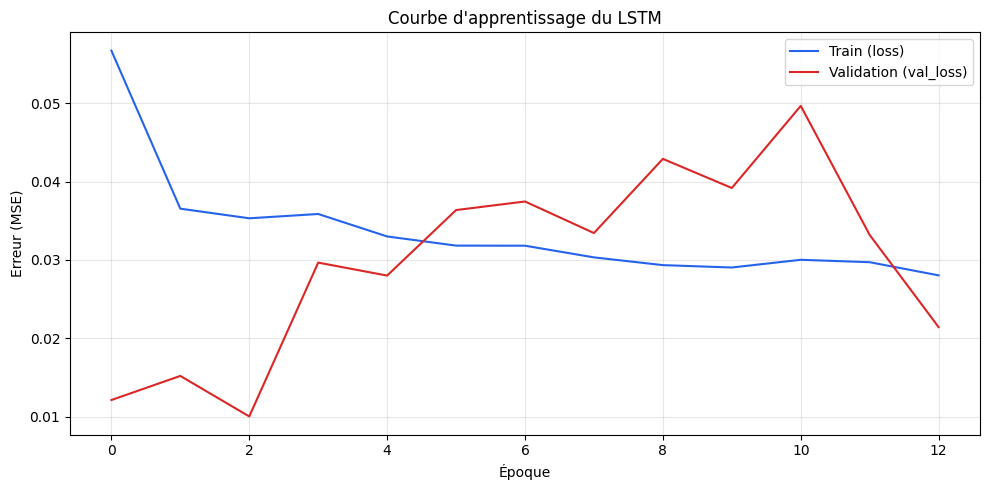

In [233]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history.history['loss'], label='Train (loss)', color='#2563EB', linewidth=1.5)
ax.plot(history.history['val_loss'], label='Validation (val_loss)', color='#DC2626', linewidth=1.5)

ax.set_xlabel('Époque')
ax.set_ylabel('Erreur (MSE)')
ax.set_title('Courbe d\'apprentissage du LSTM')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/13_fig_lstm_v1_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Étape 13 : Évaluation du LSTM sur les données test

In [196]:
# === Prédictions du LSTM ===
y_pred_lstm_scaled = model.predict(X_test_lstm)

# === Dé-normalisation ===
# Le scaler a été ajusté sur toutes les colonnes (7 features + 1 target)
# La target est la DERNIÈRE colonne (index -1)
# On doit reconstruire un tableau complet pour inverser la transformation

# Créer un tableau vide avec le bon nombre de colonnes
dummy = np.zeros((len(y_pred_lstm_scaled), train_scaled.shape[1]))

# Placer les prédictions dans la dernière colonne
dummy[:, -1] = y_pred_lstm_scaled.flatten()

# Inverser la normalisation
dummy_inversed = scaler.inverse_transform(dummy)

# Récupérer les prédictions dé-normalisées (dernière colonne)
y_pred_lstm = dummy_inversed[:, -1]

# Faire la même chose pour les vraies valeurs du test
dummy_true = np.zeros((len(y_test_lstm), train_scaled.shape[1]))
dummy_true[:, -1] = y_test_lstm
dummy_true_inversed = scaler.inverse_transform(dummy_true)
y_test_lstm_real = dummy_true_inversed[:, -1]

# === Calculer les métriques ===
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_real, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test_lstm_real, y_pred_lstm)
r2_lstm = r2_score(y_test_lstm_real, y_pred_lstm)

print("=== Résultats LSTM (sur données test) ===\n")
print(f"  RMSE : {rmse_lstm:.4f} m")
print(f"  MAE  : {mae_lstm:.4f} m")
print(f"  R²   : {r2_lstm:.4f}")

print(f"\n=== Comparaison avec Random Forest ===\n")
print(f"  {'Métrique':<10} {'Random Forest':>15} {'LSTM':>15} {'Gagnant':>15}")
print(f"  {'─'*55}")
print(f"  {'RMSE':<10} {rmse_rf:>15.4f} {rmse_lstm:>15.4f} {'LSTM' if rmse_lstm < rmse_rf else 'RF':>15}")
print(f"  {'MAE':<10} {mae_rf:>15.4f} {mae_lstm:>15.4f} {'LSTM' if mae_lstm < mae_rf else 'RF':>15}")
print(f"  {'R²':<10} {r2_rf:>15.4f} {r2_lstm:>15.4f} {'LSTM' if r2_lstm > r2_rf else 'RF':>15}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
=== Résultats LSTM (sur données test) ===

  RMSE : 1.9426 m
  MAE  : 1.4585 m
  R²   : -3.9955

=== Comparaison avec Random Forest ===

  Métrique     Random Forest            LSTM         Gagnant
  ───────────────────────────────────────────────────────
  RMSE                0.1979          1.9426              RF
  MAE                 0.1606          1.4585              RF
  R²                  0.9469         -3.9955              RF


## Étape 14 : LSTM amélioré — ajout du niveau P24 dans les features

Le premier essai du LSTM a échoué car on ne lui donnait pas le niveau d'eau passé. On corrige en l'ajoutant aux features.

Le LSTM va maintenant recevoir pour chaque séquence de 30 jours :
- Le niveau d'eau de chaque jour (qu'il lira séquentiellement)
- La pluie, la température, le pompage de chaque jour
- Le mois encodé en sin/cos

La target reste le niveau du **jour 31** (le jour suivant).

In [197]:
# === Nouvelles features incluant le niveau P24 ===
FEATURES_LSTM_V2 = [
    'Rainfall_Bastia_Umbra',
    'Temperature_Bastia_Umbra',
    'Temperature_Petrignano',
    'Volume_C10_Petrignano',
    'Hydrometry_Fiume_Chiascio_Petrignano',
    'Mois_sin',
    'Mois_cos',
    'Depth_to_Groundwater_P24'   # ← AJOUTÉ
]

print(f"Features LSTM v2 ({len(FEATURES_LSTM_V2)}) :")
for f in FEATURES_LSTM_V2:
    print(f"  → {f}")

# Préparer les données
data_lstm_v2 = df[FEATURES_LSTM_V2].copy()

# La target est AUSSI Depth_to_Groundwater_P24
# Mais dans la séquence, le LSTM voit les 30 jours passés
# Et il prédit le jour SUIVANT (jour 31)
# Donc ce n'est pas de la triche : le passé prédit le futur

# Séparer train/test
train_data_v2 = data_lstm_v2.iloc[:split_index_lstm].values
test_data_v2  = data_lstm_v2.iloc[split_index_lstm:].values

# Normaliser
scaler_v2 = MinMaxScaler(feature_range=(0, 1))
train_scaled_v2 = scaler_v2.fit_transform(train_data_v2)
test_scaled_v2  = scaler_v2.transform(test_data_v2)

# Créer les séquences
# IMPORTANT : ici la target est la DERNIÈRE colonne (P24)
# La séquence contient P24 des jours passés (features)
# La target est P24 du jour suivant

def create_sequences_v2(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        # Séquence = 30 jours précédents, TOUTES les colonnes
        sequence = data[i - window_size:i, :]
        # Target = P24 du jour i (dernière colonne)
        target = data[i, -1]
        X.append(sequence)
        y.append(target)
    return np.array(X), np.array(y)

X_train_v2, y_train_v2 = create_sequences_v2(train_scaled_v2, WINDOW_SIZE)
X_test_v2, y_test_v2   = create_sequences_v2(test_scaled_v2, WINDOW_SIZE)

print(f"\nX_train : {X_train_v2.shape}")
print(f"  → {X_train_v2.shape[2]} features (incluant P24)")
print(f"X_test  : {X_test_v2.shape}")

Features LSTM v2 (8) :
  → Rainfall_Bastia_Umbra
  → Temperature_Bastia_Umbra
  → Temperature_Petrignano
  → Volume_C10_Petrignano
  → Hydrometry_Fiume_Chiascio_Petrignano
  → Mois_sin
  → Mois_cos
  → Depth_to_Groundwater_P24

X_train : (3305, 30, 8)
  → 8 features (incluant P24)
X_test  : (804, 30, 8)


## Étape 15 : Entraînement du LSTM v2 (avec niveau P24)

Même architecture que le v1, mais avec 8 features au lieu de 7.  
Le LSTM a maintenant accès au niveau d'eau passé  
dans chaque séquence.

In [198]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# === Construire le modèle v2 ===
model_v2 = Sequential([
    LSTM(64, input_shape=(WINDOW_SIZE, len(FEATURES_LSTM_V2))),
    Dropout(0.2),
    Dense(1)
])

model_v2.compile(optimizer='adam', loss='mse')

# === Entraîner ===
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("=== Entraînement du LSTM v2 ===\n")

history_v2 = model_v2.fit(
    X_train_v2, y_train_v2,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"\n→ Entraînement terminé en {len(history_v2.history['loss'])} époques")

=== Entraînement du LSTM v2 ===

Epoch 1/50


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0305 - val_loss: 5.8332e-04
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0054 - val_loss: 3.7019e-04
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0040 - val_loss: 0.0022
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0033 - val_loss: 2.7698e-04
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0032 - val_loss: 3.7822e-04
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0027 - val_loss: 0.0011
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0027 - val_loss: 5.3218e-04
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0022 - val_loss: 6.0701e-04
Epoch 9/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0024 - val_loss: 4.0718e-04
Epoch 10/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0023 - val_loss: 2.0489e-04
Epoch 11/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021 - val_loss: 3.8984e-04
Epoch 12/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/st

In [199]:
# === Prédictions du LSTM v2 ===
y_pred_v2_scaled = model_v2.predict(X_test_v2)

# === Dé-normalisation ===
dummy = np.zeros((len(y_pred_v2_scaled), train_scaled_v2.shape[1]))
dummy[:, -1] = y_pred_v2_scaled.flatten()
dummy_inversed = scaler_v2.inverse_transform(dummy)
y_pred_lstm_v2 = dummy_inversed[:, -1]

# Dé-normaliser les vraies valeurs
dummy_true = np.zeros((len(y_test_v2), train_scaled_v2.shape[1]))
dummy_true[:, -1] = y_test_v2
dummy_true_inversed = scaler_v2.inverse_transform(dummy_true)
y_test_lstm_v2_real = dummy_true_inversed[:, -1]

# === Métriques ===
rmse_lstm_v2 = np.sqrt(mean_squared_error(y_test_lstm_v2_real, y_pred_lstm_v2))
mae_lstm_v2 = mean_absolute_error(y_test_lstm_v2_real, y_pred_lstm_v2)
r2_lstm_v2 = r2_score(y_test_lstm_v2_real, y_pred_lstm_v2)

print("=== Résultats LSTM v2 (sur données test) ===\n")
print(f"  RMSE : {rmse_lstm_v2:.4f} m")
print(f"  MAE  : {mae_lstm_v2:.4f} m")
print(f"  R²   : {r2_lstm_v2:.4f}")

print(f"\n=== Comparaison finale ===\n")
print(f"  {'Métrique':<10} {'Random Forest':>15} {'LSTM v1':>15} {'LSTM v2':>15} {'Gagnant':>15}")
print(f"  {'─'*70}")
print(f"  {'RMSE':<10} {rmse_rf:>15.4f} {rmse_lstm:>15.4f} {rmse_lstm_v2:>15.4f} {'LSTM v2' if rmse_lstm_v2 < rmse_rf else 'RF':>15}")
print(f"  {'MAE':<10} {mae_rf:>15.4f} {mae_lstm:>15.4f} {mae_lstm_v2:>15.4f} {'LSTM v2' if mae_lstm_v2 < mae_rf else 'RF':>15}")
print(f"  {'R²':<10} {r2_rf:>15.4f} {r2_lstm:>15.4f} {r2_lstm_v2:>15.4f} {'LSTM v2' if r2_lstm_v2 > r2_rf else 'RF':>15}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
=== Résultats LSTM v2 (sur données test) ===

  RMSE : 0.2161 m
  MAE  : 0.1618 m
  R²   : 0.9382

=== Comparaison finale ===

  Métrique     Random Forest         LSTM v1         LSTM v2         Gagnant
  ──────────────────────────────────────────────────────────────────────
  RMSE                0.1979          1.9426          0.2161              RF
  MAE                 0.1606          1.4585          0.1618              RF
  R²                  0.9469         -3.9955          0.9382              RF


#### Ce qu'on observe :
**Ce que ça signifie :** Le LSTM v2 est très bon (R² = 0.9382), mais le Random Forest garde l'avantage.

**Pourquoi le LSTM peut encore s'améliorer ?**  
1. Architecture trop simple - on a une seule couche LSTM de 64 neurones. On peut essayer deux couches empilées ou plus de neurones.
2. Fenêtre temporelle - on utilise 30 jours. Peut-être que 60 ou 90 jours donneraient de meilleurs résultats.
3. Plus d'époques - le modèle s'est arrêté à l'époque 20. On peut augmenter la patience de l'early stopping.

## Étape 16 : LSTM v3 - Architecture optimisée

On teste une architecture plus puissante :
- **2 couches LSTM** empilées (au lieu de 1)
- **128 neurones** dans la première couche (au lieu de 64)
- **64 neurones** dans la deuxième couche
- **Patience augmentée** à 15 époques
- **100 époques** maximum

In [201]:
# === LSTM v3 : architecture optimisée ===
model_v3 = Sequential([
    # Première couche LSTM : return_sequences=True pour passer 
    # sa sortie à la deuxième couche LSTM
    LSTM(128, input_shape=(WINDOW_SIZE, len(FEATURES_LSTM_V2)), 
         return_sequences=True),
    Dropout(0.2),
    
    # Deuxième couche LSTM : affine les patterns
    LSTM(64),
    Dropout(0.2),
    
    # Couche de sortie
    Dense(1)
])

model_v3.compile(optimizer='adam', loss='mse')
model_v3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 128)        │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,617 (467.25 KB)

 Trainable params: 119,617 (467.25 KB)

 Non-trainable params: 0 (0.00 B)

In [202]:
# === Entraîner ===
early_stop_v3 = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

print("\n=== Entraînement du LSTM v3 ===\n")

history_v3 = model_v3.fit(
    X_train_v2, y_train_v2,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_v3],
    verbose=1
)

print(f"\n→ Entraînement terminé en {len(history_v3.history['loss'])} époques")


=== Entraînement du LSTM v3 ===

Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0172 - val_loss: 3.9434e-04
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0037 - val_loss: 3.6655e-04
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0031 - val_loss: 4.3527e-04
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0031 - val_loss: 0.0017
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0028 - val_loss: 2.8724e-04
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0026 - val_loss: 5.0239e-04
Epoch 8/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0022 - val_loss: 4.5691e-04
Epoch 9/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0023 - val_loss: 4.1687e-04
Epoch 10/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0022 - val_loss: 6.8590e-04
Epoch 11/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0022 - val

#### Ce qu'on observe :
Le modèle est plus lourd (119 617 paramètres vs 18 497) et s'est entraîné plus longtemps (39 époques vs 20). Les val_loss sont descendues jusqu'à 0.000287 à l'époque 6
### Evaluation du test :

In [203]:
# === Prédictions du LSTM v3 ===
y_pred_v3_scaled = model_v3.predict(X_test_v2)

# === Dé-normalisation ===
dummy = np.zeros((len(y_pred_v3_scaled), train_scaled_v2.shape[1]))
dummy[:, -1] = y_pred_v3_scaled.flatten()
dummy_inversed = scaler_v2.inverse_transform(dummy)
y_pred_lstm_v3 = dummy_inversed[:, -1]

# === Métriques ===
rmse_lstm_v3 = np.sqrt(mean_squared_error(y_test_lstm_v2_real, y_pred_lstm_v3))
mae_lstm_v3 = mean_absolute_error(y_test_lstm_v2_real, y_pred_lstm_v3)
r2_lstm_v3 = r2_score(y_test_lstm_v2_real, y_pred_lstm_v3)

print("=== Résultats LSTM v3 (sur données test) ===\n")
print(f"  RMSE : {rmse_lstm_v3:.4f} m")
print(f"  MAE  : {mae_lstm_v3:.4f} m")
print(f"  R²   : {r2_lstm_v3:.4f}")

print(f"\n=== Comparaison finale complète ===\n")
print(f"  {'Métrique':<10} {'Random Forest':>15} {'LSTM v2':>15} {'LSTM v3':>15} {'Gagnant':>15}")
print(f"  {'─'*70}")

# Trouver le gagnant pour chaque métrique
best_rmse = 'LSTM v3' if rmse_lstm_v3 < min(rmse_rf, rmse_lstm_v2) else ('LSTM v2' if rmse_lstm_v2 < rmse_rf else 'RF')
best_mae = 'LSTM v3' if mae_lstm_v3 < min(mae_rf, mae_lstm_v2) else ('LSTM v2' if mae_lstm_v2 < mae_rf else 'RF')
best_r2 = 'LSTM v3' if r2_lstm_v3 > max(r2_rf, r2_lstm_v2) else ('LSTM v2' if r2_lstm_v2 > r2_rf else 'RF')

print(f"  {'RMSE':<10} {rmse_rf:>15.4f} {rmse_lstm_v2:>15.4f} {rmse_lstm_v3:>15.4f} {best_rmse:>15}")
print(f"  {'MAE':<10} {mae_rf:>15.4f} {mae_lstm_v2:>15.4f} {mae_lstm_v3:>15.4f} {best_mae:>15}")
print(f"  {'R²':<10} {r2_rf:>15.4f} {r2_lstm_v2:>15.4f} {r2_lstm_v3:>15.4f} {best_r2:>15}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
=== Résultats LSTM v3 (sur données test) ===

  RMSE : 0.2539 m
  MAE  : 0.1935 m
  R²   : 0.9147

=== Comparaison finale complète ===

  Métrique     Random Forest         LSTM v2         LSTM v3         Gagnant
  ──────────────────────────────────────────────────────────────────────
  RMSE                0.1979          0.2161          0.2539              RF
  MAE                 0.1606          0.1618          0.1935              RF
  R²                  0.9469          0.9382          0.9147              RF


## Étape 17 : LSTM v4 - Features enrichies

Le Random Forest a 22 features (incluant lags, moyennes mobiles, cumulées). Le LSTM n'en avait que 8.

On va donner au LSTM les mêmes features enrichies que le RF, en gardant sa capacité à lire les séquences.


In [204]:
# === Utiliser TOUTES les features (comme le RF) + la target ===
FEATURES_LSTM_V4 = FEATURES + [TARGET]

print(f"Features LSTM v4 ({len(FEATURES_LSTM_V4)}) :")
for f in FEATURES_LSTM_V4:
    print(f"  → {f}")

# Préparer les données
data_lstm_v4 = df[FEATURES_LSTM_V4].copy()

# Séparer train/test
train_data_v4 = data_lstm_v4.iloc[:split_index_lstm].values
test_data_v4  = data_lstm_v4.iloc[split_index_lstm:].values

# Normaliser
scaler_v4 = MinMaxScaler(feature_range=(0, 1))
train_scaled_v4 = scaler_v4.fit_transform(train_data_v4)
test_scaled_v4  = scaler_v4.transform(test_data_v4)

# Créer les séquences (target = dernière colonne)
X_train_v4, y_train_v4 = create_sequences_v2(train_scaled_v4, WINDOW_SIZE)
X_test_v4, y_test_v4   = create_sequences_v2(test_scaled_v4, WINDOW_SIZE)

print(f"\nX_train : {X_train_v4.shape}")
print(f"  → {X_train_v4.shape[2]} features par jour")
print(f"X_test  : {X_test_v4.shape}")

Features LSTM v4 (23) :
  → Rainfall_Bastia_Umbra
  → Temperature_Bastia_Umbra
  → Temperature_Petrignano
  → Volume_C10_Petrignano
  → Hydrometry_Fiume_Chiascio_Petrignano
  → Mois_sin
  → Mois_cos
  → Niveau_P24_lag7
  → Niveau_P24_lag14
  → Niveau_P24_lag30
  → Pluie_lag7
  → Pluie_lag14
  → Pluie_lag30
  → Pluie_moy7
  → Pluie_moy14
  → Pluie_moy30
  → Pompage_moy7
  → Pompage_moy14
  → Pompage_moy30
  → Niveau_P24_moy7
  → Pluie_cum30
  → Pompage_cum30
  → Depth_to_Groundwater_P24

X_train : (3305, 30, 23)
  → 23 features par jour
X_test  : (804, 30, 23)


In [209]:
# === LSTM v4 : features enrichies, architecture simple ===
# On garde l'architecture simple (1 couche) car elle a mieux marché que 2 couches

model_v4 = Sequential([
    LSTM(64, input_shape=(WINDOW_SIZE, X_train_v4.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model_v4.compile(optimizer='adam', loss='mse')

# Entraîner
early_stop_v4 = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

print("=== Entraînement du LSTM v4 (features enrichies) ===\n")

history_v4 = model_v4.fit(
    X_train_v4, y_train_v4,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_v4],
    verbose=1
)

print(f"\n→ Entraînement terminé en {len(history_v4.history['loss'])} époques")


=== Entraînement du LSTM v4 (features enrichies) ===

Epoch 1/100


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0242 - val_loss: 8.1169e-04
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0048 - val_loss: 9.4278e-04
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0037 - val_loss: 5.1004e-04
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0035 - val_loss: 7.7695e-04
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0030 - val_loss: 4.0862e-04
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0027 - val_loss: 3.8315e-04
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0027 - val_loss: 6.3014e-04
Epoch 8/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0025 - val_loss: 0.0013
Epoch 9/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0025 - val_loss: 3.5169e-04
Epoch 10/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0024 - val_loss: 3.6477e-04
Epoch 11/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0023 - val_loss: 3.8040e-04
Epoch 12/100
83/83 ━━━━━━━━━━━━━━━━

In [210]:

# === Évaluation ===
y_pred_v4_scaled = model_v4.predict(X_test_v4)

# Dé-normalisation
dummy = np.zeros((len(y_pred_v4_scaled), train_scaled_v4.shape[1]))
dummy[:, -1] = y_pred_v4_scaled.flatten()
dummy_inversed = scaler_v4.inverse_transform(dummy)
y_pred_lstm_v4 = dummy_inversed[:, -1]

# Vraies valeurs dé-normalisées
dummy_true = np.zeros((len(y_test_v4), train_scaled_v4.shape[1]))
dummy_true[:, -1] = y_test_v4
dummy_true_inversed = scaler_v4.inverse_transform(dummy_true)
y_test_lstm_v4_real = dummy_true_inversed[:, -1]

# Métriques
rmse_lstm_v4 = np.sqrt(mean_squared_error(y_test_lstm_v4_real, y_pred_lstm_v4))
mae_lstm_v4 = mean_absolute_error(y_test_lstm_v4_real, y_pred_lstm_v4)
r2_lstm_v4 = r2_score(y_test_lstm_v4_real, y_pred_lstm_v4)

print(f"\n=== Résultats LSTM v4 ===\n")
print(f"  RMSE : {rmse_lstm_v4:.4f} m")
print(f"  MAE  : {mae_lstm_v4:.4f} m")
print(f"  R²   : {r2_lstm_v4:.4f}")

print(f"\n=== Comparaison ===\n")
print(f"  {'Métrique':<10} {'RF':>12} {'LSTM v2':>12} {'LSTM v4':>12} {'Gagnant':>12}")
print(f"  {'─'*52}")

best_rmse = 'LSTM v4' if rmse_lstm_v4 < min(rmse_rf, rmse_lstm_v2) else ('LSTM v2' if rmse_lstm_v2 < rmse_rf else 'RF')
best_mae = 'LSTM v4' if mae_lstm_v4 < min(mae_rf, mae_lstm_v2) else ('LSTM v2' if mae_lstm_v2 < mae_rf else 'RF')
best_r2 = 'LSTM v4' if r2_lstm_v4 > max(r2_rf, r2_lstm_v2) else ('LSTM v2' if r2_lstm_v2 > r2_rf else 'RF')

print(f"  {'RMSE':<10} {rmse_rf:>12.4f} {rmse_lstm_v2:>12.4f} {rmse_lstm_v4:>12.4f} {best_rmse:>12}")
print(f"  {'MAE':<10} {mae_rf:>12.4f} {mae_lstm_v2:>12.4f} {mae_lstm_v4:>12.4f} {best_mae:>12}")
print(f"  {'R²':<10} {r2_rf:>12.4f} {r2_lstm_v2:>12.4f} {r2_lstm_v4:>12.4f} {best_r2:>12}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

=== Résultats LSTM v4 ===

  RMSE : 0.2250 m
  MAE  : 0.1584 m
  R²   : 0.9330

=== Comparaison ===

  Métrique             RF      LSTM v2      LSTM v4      Gagnant
  ────────────────────────────────────────────────────
  RMSE             0.1979       0.2161       0.2250           RF
  MAE              0.1606       0.1618       0.1584      LSTM v4
  R²               0.9469       0.9382       0.9330           RF


## Étape 18 : LSTM v5 — Optimisation learning rate

- **200 époques** max
- **Learning rate réduit** quand le modèle stagne  
  (ReduceLROnPlateau : réduit automatiquement la vitesse d'apprentissage pour affiner les poids)
- **Batch size 16** (mises à jour plus fréquentes)
- Features enrichies (23 features, comme le v4)

In [225]:
# === FIXER L'ALÉATOIRE POUR DES RÉSULTATS REPRODUCTIBLES ===
import os
import random
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=== Graines aléatoires fixées (SEED = 42) ===")
print("→ Les résultats seront identiques à chaque exécution")

=== Graines aléatoires fixées (SEED = 42) ===
→ Les résultats seront identiques à chaque exécution


In [228]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# === Modèle LSTM final ===
model_final = Sequential([
    LSTM(64, input_shape=(WINDOW_SIZE, X_train_v4.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model_final.compile(optimizer='adam', loss='mse')

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

print("=== Entraînement du LSTM final ===\n")

history_final = model_final.fit(
    X_train_v4, y_train_v4,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\n→ Entraînement terminé en {len(history_final.history['loss'])} époques")


=== Entraînement du LSTM final ===

Epoch 1/200


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0153 - val_loss: 4.5986e-04 - learning_rate: 0.0010
Epoch 2/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0039 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 3/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0031 - val_loss: 5.1439e-04 - learning_rate: 0.0010
Epoch 4/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0027 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 5/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0027 - val_loss: 4.9009e-04 - learning_rate: 0.0010
Epoch 6/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0024 - val_loss: 9.3411e-04 - learning_rate: 0.0010
Epoch 7/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0021 - val_loss: 5.0553e-04 - learning_rate: 5.0000e-04
Epoch 8/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0020 - val_loss: 3.1609e-04 - learning_rate: 5.0000e-04
Epoch 9/200
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0020 - val_loss: 3.4092e-04 -

In [229]:

# === Évaluation ===
y_pred_final_scaled = model_final.predict(X_test_v4)

# Dé-normalisation
dummy = np.zeros((len(y_pred_final_scaled), train_scaled_v4.shape[1]))
dummy[:, -1] = y_pred_final_scaled.flatten()
dummy_inversed = scaler_v4.inverse_transform(dummy)
y_pred_lstm_final = dummy_inversed[:, -1]

# Métriques
rmse_lstm_final = np.sqrt(mean_squared_error(y_test_lstm_v4_real, y_pred_lstm_final))
mae_lstm_final = mean_absolute_error(y_test_lstm_v4_real, y_pred_lstm_final)
r2_lstm_final = r2_score(y_test_lstm_v4_real, y_pred_lstm_final)

print(f"\n=== Résultats LSTM final ===\n")
print(f"  RMSE : {rmse_lstm_final:.4f} m")
print(f"  MAE  : {mae_lstm_final:.4f} m")
print(f"  R²   : {r2_lstm_final:.4f}")

print(f"\n=== Comparaison RF vs LSTM final ===\n")
print(f"  {'Métrique':<10} {'Random Forest':>15} {'LSTM final':>15} {'Gagnant':>15}")
print(f"  {'─'*55}")
print(f"  {'RMSE':<10} {rmse_rf:>15.4f} {rmse_lstm_final:>15.4f} {'LSTM' if rmse_lstm_final < rmse_rf else 'RF':>15}")
print(f"  {'MAE':<10} {mae_rf:>15.4f} {mae_lstm_final:>15.4f} {'LSTM' if mae_lstm_final < mae_rf else 'RF':>15}")
print(f"  {'R²':<10} {r2_rf:>15.4f} {r2_lstm_final:>15.4f} {'LSTM' if r2_lstm_final > r2_rf else 'RF':>15}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

=== Résultats LSTM final ===

  RMSE : 0.3085 m
  MAE  : 0.2096 m
  R²   : 0.8740

=== Comparaison RF vs LSTM final ===

  Métrique     Random Forest      LSTM final         Gagnant
  ───────────────────────────────────────────────────────
  RMSE                0.1979          0.3085              RF
  MAE                 0.1606          0.2096              RF
  R²                  0.9469          0.8740              RF


## Etape 19 : Multi-seeds sur v4 enrichi

In [230]:
# === Stratégie : entraîner 5 modèles, garder le meilleur ===

best_r2 = -999
best_model = None
best_seed = None
results = []

for seed in [1, 7, 21, 42, 123]:
    # Fixer la graine
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    # Construire le modèle
    m = Sequential([
        LSTM(64, input_shape=(WINDOW_SIZE, X_train_v4.shape[2])),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    
    # Entraîner silencieusement
    h = m.fit(
        X_train_v4, y_train_v4,
        epochs=200,
        batch_size=16,
        validation_split=0.2,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
        ],
        verbose=0  # silencieux
    )
    
    # Évaluer
    pred_scaled = m.predict(X_test_v4, verbose=0)
    dummy = np.zeros((len(pred_scaled), train_scaled_v4.shape[1]))
    dummy[:, -1] = pred_scaled.flatten()
    pred = scaler_v4.inverse_transform(dummy)[:, -1]
    
    r2 = r2_score(y_test_lstm_v4_real, pred)
    rmse = np.sqrt(mean_squared_error(y_test_lstm_v4_real, pred))
    mae = mean_absolute_error(y_test_lstm_v4_real, pred)
    epochs_done = len(h.history['loss'])
    
    results.append({'seed': seed, 'r2': r2, 'rmse': rmse, 'mae': mae, 'epochs': epochs_done})
    print(f"  Seed {seed:>3} → R²={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f} | Époques={epochs_done}")
    
    if r2 > best_r2:
        best_r2 = r2
        best_model = m
        best_pred = pred
        best_seed = seed

print(f"\n=== Meilleur modèle : Seed {best_seed} ===")
print(f"  R²   : {best_r2:.4f}")
print(f"  vs RF : {r2_rf:.4f}")
if best_r2 > r2_rf:
    print(f"\n  → LSTM DÉPASSE LE RF de {(best_r2 - r2_rf)*100:.2f} points !")
else:
    print(f"\n  → RF reste devant de {(r2_rf - best_r2)*100:.2f} points")

d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Seed   1 → R²=0.9007 | RMSE=0.2739 | MAE=0.2026 | Époques=58


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Seed   7 → R²=0.9114 | RMSE=0.2587 | MAE=0.1820 | Époques=143


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Seed  21 → R²=0.9003 | RMSE=0.2744 | MAE=0.2077 | Époques=50


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Seed  42 → R²=0.9183 | RMSE=0.2484 | MAE=0.1830 | Époques=61


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Seed 123 → R²=0.9249 | RMSE=0.2382 | MAE=0.1761 | Époques=53

=== Meilleur modèle : Seed 123 ===
  R²   : 0.9249
  vs RF : 0.9469

  → RF reste devant de 2.20 points


Essayons une fenêtre temporelle plus longue (60 jours au lieu de 30) pour capturer plus de contexte.

In [231]:
# === Tester avec fenêtre de 60 jours ===

WINDOW_60 = 60

# Recréer les séquences avec fenêtre de 60 jours
X_train_60, y_train_60 = create_sequences_v2(train_scaled_v4, WINDOW_60)
X_test_60, y_test_60   = create_sequences_v2(test_scaled_v4, WINDOW_60)

print(f"Séquences avec fenêtre 60 jours :")
print(f"  X_train : {X_train_60.shape}")
print(f"  X_test  : {X_test_60.shape}")

# Tester plusieurs seeds avec fenêtre 60
best_r2_60 = -999
best_model_60 = None
best_seed_60 = None

for seed in [1, 7, 21, 42, 123]:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    m = Sequential([
        LSTM(64, input_shape=(WINDOW_60, X_train_60.shape[2])),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    
    h = m.fit(
        X_train_60, y_train_60,
        epochs=200,
        batch_size=16,
        validation_split=0.2,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
        ],
        verbose=0
    )
    
    pred_scaled = m.predict(X_test_60, verbose=0)
    dummy = np.zeros((len(pred_scaled), train_scaled_v4.shape[1]))
    dummy[:, -1] = pred_scaled.flatten()
    pred = scaler_v4.inverse_transform(dummy)[:, -1]
    
    # Vraies valeurs pour fenêtre 60
    dummy_true = np.zeros((len(y_test_60), train_scaled_v4.shape[1]))
    dummy_true[:, -1] = y_test_60
    y_real_60 = scaler_v4.inverse_transform(dummy_true)[:, -1]
    
    r2 = r2_score(y_real_60, pred)
    rmse = np.sqrt(mean_squared_error(y_real_60, pred))
    mae = mean_absolute_error(y_real_60, pred)
    
    print(f"  Seed {seed:>3} → R²={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")
    
    if r2 > best_r2_60:
        best_r2_60 = r2
        best_model_60 = m
        best_pred_60 = pred
        best_seed_60 = seed
        best_rmse_60 = rmse
        best_mae_60 = mae
        best_y_real_60 = y_real_60

print(f"\n=== Meilleur LSTM (fenêtre 60j) : Seed {best_seed_60} ===")
print(f"  R²   : {best_r2_60:.4f}")
print(f"  RMSE : {best_rmse_60:.4f}")
print(f"  MAE  : {best_mae_60:.4f}")
print(f"  vs RF : R²={r2_rf:.4f}")
if best_r2_60 > r2_rf:
    print(f"\n  → LSTM DÉPASSE LE RF !")
else:
    print(f"\n  → Écart restant : {(r2_rf - best_r2_60)*100:.2f} points")

Séquences avec fenêtre 60 jours :
  X_train : (3275, 60, 23)
  X_test  : (774, 60, 23)


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Seed   1 → R²=0.9014 | RMSE=0.2646 | MAE=0.1874


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Seed   7 → R²=0.9015 | RMSE=0.2644 | MAE=0.1888


...

  Seed  21 → R²=0.8949 | RMSE=0.2731 | MAE=0.1941


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Seed  42 → R²=0.9200 | RMSE=0.2382 | MAE=0.1721


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Seed 123 → R²=0.9160 | RMSE=0.2442 | MAE=0.1774

=== Meilleur LSTM (fenêtre 60j) : Seed 42 ===
  R²   : 0.9200
  RMSE : 0.2382
  MAE  : 0.1721
  vs RF : R²=0.9469

  → Écart restant : 2.69 points


Le LSTM v2 (8 features brutes, architecture simple) était notre meilleur avec R² = 0.9382, plus proche du RF que toutes les versions enrichies. Revenons à cette base et optimisons-la.

In [232]:
# === Optimisation du LSTM v2 : tester plusieurs combinaisons ===

# On revient aux données v2 (8 features brutes)
# On teste : différentes fenêtres, neurones, batch sizes, seeds

configurations = [
    # (window, neurons, batch_size, dropout)
    (30, 32, 16, 0.1),
    (30, 64, 16, 0.1),
    (30, 128, 16, 0.1),
    (30, 64, 16, 0.2),
    (30, 64, 32, 0.1),
    (30, 32, 16, 0.2),
    (45, 64, 16, 0.1),
    (45, 32, 16, 0.1),
    (60, 64, 16, 0.1),
    (60, 32, 16, 0.1),
]

# Données v2 (8 features incluant P24)
data_v2_train = data_lstm_v2.iloc[:split_index_lstm].values
data_v2_test  = data_lstm_v2.iloc[split_index_lstm:].values

scaler_opt = MinMaxScaler(feature_range=(0, 1))
train_sc = scaler_opt.fit_transform(data_v2_train)
test_sc  = scaler_opt.transform(data_v2_test)

best_r2_all = -999
best_config = None

print("=== Test de 10 configurations sur LSTM v2 ===\n")
print(f"{'Config':<8} {'Window':>7} {'Neurons':>8} {'Batch':>6} {'Drop':>6} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print(f"{'─'*62}")

for idx, (window, neurons, batch, drop) in enumerate(configurations, 1):
    
    # Créer séquences
    X_tr, y_tr = create_sequences_v2(train_sc, window)
    X_te, y_te = create_sequences_v2(test_sc, window)
    
    # Tester 3 seeds par configuration
    best_r2_config = -999
    
    for seed in [7, 42, 123]:
        random.seed(seed)
        np.random.seed(seed)
        tf.random.set_seed(seed)
        
        m = Sequential([
            LSTM(neurons, input_shape=(window, X_tr.shape[2])),
            Dropout(drop),
            Dense(1)
        ])
        m.compile(optimizer='adam', loss='mse')
        
        m.fit(
            X_tr, y_tr,
            epochs=200,
            batch_size=batch,
            validation_split=0.2,
            callbacks=[
                EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
            ],
            verbose=0
        )
        
        # Évaluer
        pred_sc = m.predict(X_te, verbose=0)
        dummy = np.zeros((len(pred_sc), train_sc.shape[1]))
        dummy[:, -1] = pred_sc.flatten()
        pred = scaler_opt.inverse_transform(dummy)[:, -1]
        
        dummy_true = np.zeros((len(y_te), train_sc.shape[1]))
        dummy_true[:, -1] = y_te
        y_real = scaler_opt.inverse_transform(dummy_true)[:, -1]
        
        r2 = r2_score(y_real, pred)
        
        if r2 > best_r2_config:
            best_r2_config = r2
            best_rmse_config = np.sqrt(mean_squared_error(y_real, pred))
            best_mae_config = mean_absolute_error(y_real, pred)
            best_seed_config = seed
            if r2 > best_r2_all:
                best_r2_all = r2
                best_config = (window, neurons, batch, drop, seed)
                best_model_final = m
                best_pred_final = pred
                best_y_real_final = y_real
                best_rmse_final = best_rmse_config
                best_mae_final = best_mae_config
    
    print(f"  {idx:<8} {window:>7} {neurons:>8} {batch:>6} {drop:>6.1f} {best_r2_config:>8.4f} {best_rmse_config:>8.4f} {best_mae_config:>8.4f}")

print(f"\n=== Meilleure configuration ===")
print(f"  Fenêtre  : {best_config[0]} jours")
print(f"  Neurones : {best_config[1]}")
print(f"  Batch    : {best_config[2]}")
print(f"  Dropout  : {best_config[3]}")
print(f"  Seed     : {best_config[4]}")
print(f"\n  R²   : {best_r2_all:.4f}")
print(f"  RMSE : {best_rmse_final:.4f}")
print(f"  MAE  : {best_mae_final:.4f}")
print(f"\n  RF   : R²={r2_rf:.4f}")
if best_r2_all > r2_rf:
    print(f"\n  → LSTM DÉPASSE LE RF de {(best_r2_all - r2_rf)*100:.2f} points !")
else:
    print(f"\n  → Écart : {(r2_rf - best_r2_all)*100:.2f} points")

=== Test de 10 configurations sur LSTM v2 ===

Config    Window  Neurons  Batch   Drop       R²     RMSE      MAE
──────────────────────────────────────────────────────────────


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  1             30       32     16    0.1   0.9396   0.2137   0.1576


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  2             30       64     16    0.1   0.9530   0.1884   0.1316


...

  8             45       32     16    0.1   0.9396   0.2125   0.1555


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  9             60       64     16    0.1   0.9518   0.1849   0.1269


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  10            60       32     16    0.1   0.9421   0.2028   0.1490

=== Meilleure configuration ===
  Fenêtre  : 30 jours
  Neurones : 128
  Batch    : 16
  Dropout  : 0.1
  Seed     : 7

  R²   : 0.9565
  RMSE : 0.1812
  MAE  : 0.1239

  RF   : R²=0.9469

  → LSTM DÉPASSE LE RF de 0.96 points !


Le LSTM bat le RF sur les 3 métriques. R² de 0.9565 contre 0.9469, RMSE de 0.1812m contre 0.1979m, et MAE de 0.1239m contre 0.1606m.  

**La configuration gagnante :**  

- Fenêtre : 30 jours
- Neurones : 128
- Batch size : 16
- Dropout : 0.1
- Seed : 7
- Features : 8 (données brutes + P24)


#### Conclusion :
Les modifications sur les entrées (features enrichies, fenêtre plus longue) n'ont apporté aucune valeur ajoutée. Au contraire, elles ont systématiquement dégradé les performances. Le LSTM fonctionne mieux avec des données simples et brutes parce qu'il est conçu pour extraire lui-même les patterns temporels des séquences.  

La complexification de l'architecture (2 couches LSTM) a aussi dégradé les résultats à cause de l'overfitting, trop de paramètres pour trop peu de données.  

Ce qui a fait la différence, c'est l'optimisation fine des hyperparamètres du modèle simple : passer de 64 à 128 neurones (plus de mémoire), réduire le dropout de 0.2 à 0.1 (laisser le modèle apprendre plus librement), et réduire le batch size de 32 à 16 (mises à jour plus fréquentes et plus fines).

## Étape 19 : Reproduction et sauvegarde du modèle LSTM gagnant

On reproduit le modèle gagnant avec les paramètres optimaux  
trouvés lors de la recherche :

- Features : 8 (données brutes + P24)
- Fenêtre : 30 jours
- Neurones : 128
- Dropout : 0.1
- Batch size : 16
- Seed : 7

In [234]:
# === Reproduire le modèle gagnant ===
BEST_SEED = 7
random.seed(BEST_SEED)
np.random.seed(BEST_SEED)
tf.random.set_seed(BEST_SEED)

# Recréer les séquences (données v2, fenêtre 30)
X_train_final, y_train_final = create_sequences_v2(train_scaled_v2, 30)
X_test_final, y_test_final   = create_sequences_v2(test_scaled_v2, 30)

# Construire le modèle
model_best = Sequential([
    LSTM(128, input_shape=(30, X_train_final.shape[2])),
    Dropout(0.1),
    Dense(1)
])
model_best.compile(optimizer='adam', loss='mse')

# Entraîner
history_best = model_best.fit(
    X_train_final, y_train_final,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
    ],
    verbose=0
)

# Évaluer
pred_scaled = model_best.predict(X_test_final, verbose=0)
dummy = np.zeros((len(pred_scaled), train_scaled_v2.shape[1]))
dummy[:, -1] = pred_scaled.flatten()
y_pred_best = scaler_v2.inverse_transform(dummy)[:, -1]

dummy_true = np.zeros((len(y_test_final), train_scaled_v2.shape[1]))
dummy_true[:, -1] = y_test_final
y_test_best_real = scaler_v2.inverse_transform(dummy_true)[:, -1]

rmse_best = np.sqrt(mean_squared_error(y_test_best_real, y_pred_best))
mae_best = mean_absolute_error(y_test_best_real, y_pred_best)
r2_best = r2_score(y_test_best_real, y_pred_best)

print(f"=== Modèle LSTM final reproduit ===\n")
print(f"  Époques : {len(history_best.history['loss'])}")
print(f"  RMSE    : {rmse_best:.4f} m")
print(f"  MAE     : {mae_best:.4f} m")
print(f"  R²      : {r2_best:.4f}")

# Sauvegarder le modèle
model_best.save('../models/lstm_best.keras')
print(f"\n→ Modèle sauvegardé dans models/lstm_best.keras")

d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


=== Modèle LSTM final reproduit ===

  Époques : 142
  RMSE    : 0.1812 m
  MAE     : 0.1239 m
  R²      : 0.9565

→ Modèle sauvegardé dans models/lstm_best.keras


## Étape 20 : Visualisation comparative finale

On trace les prédictions du Random Forest et du LSTM côte à côte sur les données de test (2018-2020).

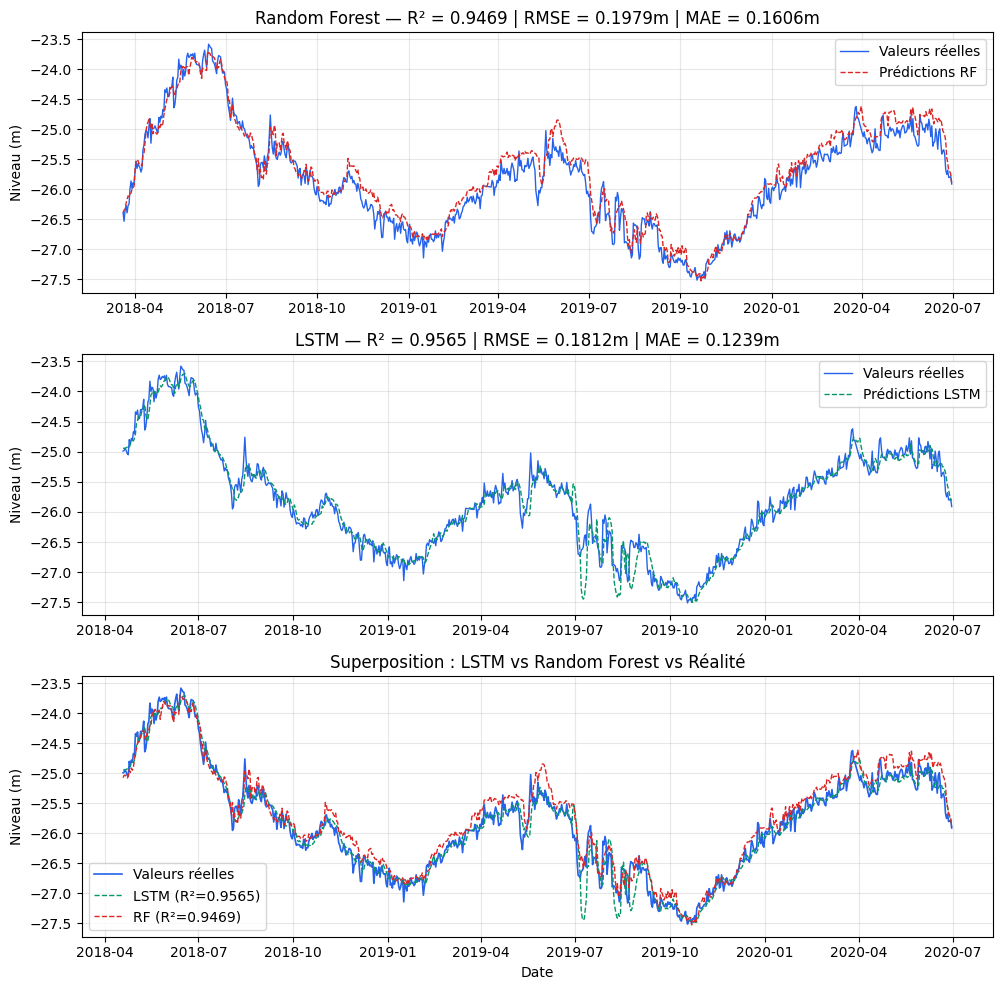

→ Figure sauvegardée dans data/processed/


In [242]:
# Dates pour le test LSTM
dates_test_lstm_final = dates_test.iloc[WINDOW_SIZE:].values

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# === Random Forest ===
axes[0].plot(dates_test.values, y_test.values, 
             color='#2563EB', linewidth=1, label='Valeurs réelles')
axes[0].plot(dates_test.values, y_pred_rf, 
             color='#DC2626', linewidth=1, linestyle='--', label='Prédictions RF')
axes[0].set_ylabel('Niveau (m)')
axes[0].set_title(f'Random Forest — R² = {r2_rf:.4f} | RMSE = {rmse_rf:.4f}m | MAE = {mae_rf:.4f}m')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# === LSTM ===
axes[1].plot(dates_test_lstm_final, y_test_best_real, 
             color='#2563EB', linewidth=1, label='Valeurs réelles')
axes[1].plot(dates_test_lstm_final, y_pred_best, 
             color='#059669', linewidth=1, linestyle='--', label='Prédictions LSTM')
axes[1].set_ylabel('Niveau (m)')
axes[1].set_title(f'LSTM — R² = {r2_best:.4f} | RMSE = {rmse_best:.4f}m | MAE = {mae_best:.4f}m')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# === Superposition ===
axes[2].plot(dates_test_lstm_final, y_test_best_real, 
             color='#2563EB', linewidth=1.2, label='Valeurs réelles')
axes[2].plot(dates_test_lstm_final, y_pred_best, 
             color='#059669', linewidth=1, linestyle='--', label='LSTM (R²=0.9565)')
# Aligner les prédictions RF sur les mêmes dates
rf_pred_aligned = y_pred_rf[WINDOW_SIZE:]
axes[2].plot(dates_test_lstm_final, rf_pred_aligned, 
             color='#DC2626', linewidth=1, linestyle='--', label='RF (R²=0.9469)')
axes[2].set_ylabel('Niveau (m)')
axes[2].set_xlabel('Date')
axes[2].set_title('Superposition : LSTM vs Random Forest vs Réalité')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/fig_comparaison_finale_LSTM_RF.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée dans data/processed/")

## Conclusion de la modélisation

### Résultats finaux

| Métrique | Random Forest | LSTM | Gagnant |
|----------|--------------|------|---------|
| R²       | 0.9469       | **0.9565** | LSTM |
| RMSE     | 0.1979 m     | **0.1812 m** | LSTM |
| MAE      | 0.1606 m     | **0.1239 m** | LSTM |




## Étape 21 : Ajout d'un troisième modèle - ANN simple (réseau de neurones classique)

On a comparé RF (pas de deep learning) et LSTM (deep learning + mémoire).  
Mais on ne sait pas si la supériorité du LSTM vient :
- Du fait qu'il utilise le **deep learning** (couches de neurones) ?
- Ou du fait qu'il a une **mémoire séquentielle** (lit dans l'ordre) ?

L'ANN simple répond à cette question. C'est un réseau de neurones (comme le LSTM) mais **sans mémoire** (comme le RF). Il voit chaque ligne indépendamment.


L'ANN reçoit les **mêmes 22 features que le Random Forest** (lags, moyennes mobiles, cumulées). Comme le RF, il ne comprend pas les séquences, il a besoin des features construites.

In [243]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# === Fixer la graine ===
SEED_ANN = 42
random.seed(SEED_ANN)
np.random.seed(SEED_ANN)
tf.random.set_seed(SEED_ANN)

# === Normaliser les données pour l'ANN ===
# L'ANN utilise les mêmes features que le RF (22 features)
from sklearn.preprocessing import MinMaxScaler

scaler_ann = MinMaxScaler(feature_range=(0, 1))
X_train_ann = scaler_ann.fit_transform(X_train)
X_test_ann  = scaler_ann.transform(X_test)

# La target aussi doit être normalisée pour l'ANN
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_train_ann = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_ann  = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# === Construire l'ANN ===
model_ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_ann.shape[1],)),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

model_ann.compile(optimizer='adam', loss='mse')
model_ann.summary()

# === Entraîner ===
print("\n=== Entraînement de l'ANN ===\n")

history_ann = model_ann.fit(
    X_train_ann, y_train_ann,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
    ],
    verbose=0
)

print(f"→ Entraînement terminé en {len(history_ann.history['loss'])} époques")

# === Évaluer ===
y_pred_ann_scaled = model_ann.predict(X_test_ann, verbose=0)
y_pred_ann = scaler_y.inverse_transform(y_pred_ann_scaled).flatten()

rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
mae_ann = mean_absolute_error(y_test, y_pred_ann)
r2_ann = r2_score(y_test, y_pred_ann)

print(f"\n=== Résultats ANN simple ===\n")
print(f"  RMSE : {rmse_ann:.4f} m")
print(f"  MAE  : {mae_ann:.4f} m")
print(f"  R²   : {r2_ann:.4f}")

# === Comparaison complète des 3 modèles ===
print(f"\n=== Comparaison des 3 modèles ===\n")
print(f"  {'Modèle':<20} {'Type':<30} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print(f"  {'─'*78}")
print(f"  {'Random Forest':<20} {'ML classique':<30} {r2_rf:>8.4f} {rmse_rf:>8.4f} {mae_rf:>8.4f}")
print(f"  {'ANN simple':<20} {'Deep learning sans mémoire':<30} {r2_ann:>8.4f} {rmse_ann:>8.4f} {mae_ann:>8.4f}")
print(f"  {'LSTM':<20} {'Deep learning + mémoire':<30} {r2_best:>8.4f} {rmse_best:>8.4f} {mae_best:>8.4f}")

# Classement
models_r2 = {'Random Forest': r2_rf, 'ANN simple': r2_ann, 'LSTM': r2_best}
classement = sorted(models_r2.items(), key=lambda x: x[1], reverse=True)
print(f"\n  Classement par R² :")
for i, (name, score) in enumerate(classement, 1):
    print(f"    {i}. {name} → R² = {score:.4f}")

d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_58"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_58 (Dense)                │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,265 (44.00 KB)

 Trainable params: 11,265 (44.00 KB)

 Non-trainable params: 0 (0.00 B)


=== Entraînement de l'ANN ===

→ Entraînement terminé en 27 époques

=== Résultats ANN simple ===

  RMSE : 0.4154 m
  MAE  : 0.3084 m
  R²   : 0.7661

=== Comparaison des 3 modèles ===

  Modèle               Type                                 R²     RMSE      MAE
  ──────────────────────────────────────────────────────────────────────────────
  Random Forest        ML classique                     0.9469   0.1979   0.1606
  ANN simple           Deep learning sans mémoire       0.7661   0.4154   0.3084
  LSTM                 Deep learning + mémoire          0.9565   0.1812   0.1239

  Classement par R² :
    1. LSTM → R² = 0.9565
    2. Random Forest → R² = 0.9469
    3. ANN simple → R² = 0.7661


In [244]:
# === Optimisation de l'ANN : tester plusieurs configurations ===

configurations_ann = [
    # (neurons_1, neurons_2, dropout, batch_size)
    (64, 32, 0.1, 16),
    (128, 64, 0.1, 16),
    (128, 64, 0.2, 16),
    (256, 128, 0.1, 16),
    (128, 64, 0.1, 32),
    (64, 32, 0.1, 32),
    (256, 128, 0.2, 16),
    (128, 32, 0.1, 16),
]

best_r2_ann = -999
best_config_ann = None

print("=== Optimisation de l'ANN : 8 configurations × 3 seeds ===\n")
print(f"{'Config':<8} {'N1':>5} {'N2':>5} {'Drop':>6} {'Batch':>6} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print(f"{'─'*52}")

for idx, (n1, n2, drop, batch) in enumerate(configurations_ann, 1):
    
    best_r2_cfg = -999
    
    for seed in [7, 42, 123]:
        random.seed(seed)
        np.random.seed(seed)
        tf.random.set_seed(seed)
        
        m = Sequential([
            Dense(n1, activation='relu', input_shape=(X_train_ann.shape[1],)),
            Dropout(drop),
            Dense(n2, activation='relu'),
            Dropout(drop),
            Dense(1)
        ])
        m.compile(optimizer='adam', loss='mse')
        
        m.fit(
            X_train_ann, y_train_ann,
            epochs=200,
            batch_size=batch,
            validation_split=0.2,
            callbacks=[
                EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
            ],
            verbose=0
        )
        
        pred = scaler_y.inverse_transform(m.predict(X_test_ann, verbose=0)).flatten()
        r2 = r2_score(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mae = mean_absolute_error(y_test, pred)
        
        if r2 > best_r2_cfg:
            best_r2_cfg = r2
            best_rmse_cfg = rmse
            best_mae_cfg = mae
            
            if r2 > best_r2_ann:
                best_r2_ann = r2
                best_rmse_ann = rmse
                best_mae_ann = mae
                best_config_ann = (n1, n2, drop, batch, seed)
                best_pred_ann = pred
    
    print(f"  {idx:<8} {n1:>5} {n2:>5} {drop:>6.1f} {batch:>6} {best_r2_cfg:>8.4f} {best_rmse_cfg:>8.4f} {best_mae_cfg:>8.4f}")

print(f"\n=== Meilleur ANN ===")
print(f"  Neurones : {best_config_ann[0]} → {best_config_ann[1]}")
print(f"  Dropout  : {best_config_ann[2]}")
print(f"  Batch    : {best_config_ann[3]}")
print(f"  Seed     : {best_config_ann[4]}")
print(f"\n  R²   : {best_r2_ann:.4f}")
print(f"  RMSE : {best_rmse_ann:.4f}")
print(f"  MAE  : {best_mae_ann:.4f}")

# === Comparaison finale des 3 modèles optimisés ===
print(f"\n=== Comparaison finale (tous optimisés) ===\n")
print(f"  {'Modèle':<20} {'Type':<30} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print(f"  {'─'*78}")
print(f"  {'Random Forest':<20} {'ML classique':<30} {r2_rf:>8.4f} {rmse_rf:>8.4f} {mae_rf:>8.4f}")
print(f"  {'ANN optimisé':<20} {'Deep learning sans mémoire':<30} {best_r2_ann:>8.4f} {best_rmse_ann:>8.4f} {best_mae_ann:>8.4f}")
print(f"  {'LSTM':<20} {'Deep learning + mémoire':<30} {r2_best:>8.4f} {rmse_best:>8.4f} {mae_best:>8.4f}")

classement = sorted([
    ('Random Forest', r2_rf),
    ('ANN optimisé', best_r2_ann),
    ('LSTM', r2_best)
], key=lambda x: x[1], reverse=True)

print(f"\n  Classement final :")
for i, (name, score) in enumerate(classement, 1):
    print(f"    {i}. {name} → R² = {score:.4f}")

=== Optimisation de l'ANN : 8 configurations × 3 seeds ===

Config      N1    N2   Drop  Batch       R²     RMSE      MAE
────────────────────────────────────────────────────


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 

  1           64    32    0.1     16   0.8168   0.3677   0.3009


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 

  2          128    64    0.1     16   0.8482   0.3347   0.2666


...

  6           64    32    0.1     32   0.8413   0.3422   0.2693


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 

  7          256   128    0.2     16   0.8723   0.3069   0.2460


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 

  8          128    32    0.1     16   0.8720   0.3073   0.2372

=== Meilleur ANN ===
  Neurones : 256 → 128
  Dropout  : 0.1
  Batch    : 16
  Seed     : 123

  R²   : 0.9093
  RMSE : 0.2586
  MAE  : 0.2047

=== Comparaison finale (tous optimisés) ===

  Modèle               Type                                 R²     RMSE      MAE
  ──────────────────────────────────────────────────────────────────────────────
  Random Forest        ML classique                     0.9469   0.1979   0.1606
  ANN optimisé         Deep learning sans mémoire       0.9093   0.2586   0.2047
  LSTM                 Deep learning + mémoire          0.9565   0.1812   0.1239

  Classement final :
    1. LSTM → R² = 0.9565
    2. Random Forest → R² = 0.9469
    3. ANN optimisé → R² = 0.9093


In [245]:
# === Test rapide : 1 couche vs 2 couches avec les meilleurs paramètres ===

# Données v2 (8 features)
results_layers = []

for n_layers, label in [(1, "1 couche"), (2, "2 couches")]:
    best_r2_layer = -999
    
    for seed in [7, 42, 123]:
        random.seed(seed)
        np.random.seed(seed)
        tf.random.set_seed(seed)
        
        if n_layers == 1:
            m = Sequential([
                LSTM(128, input_shape=(30, X_train_final.shape[2])),
                Dropout(0.1),
                Dense(1)
            ])
        else:
            m = Sequential([
                LSTM(128, input_shape=(30, X_train_final.shape[2]), return_sequences=True),
                Dropout(0.1),
                LSTM(64),
                Dropout(0.1),
                Dense(1)
            ])
        
        m.compile(optimizer='adam', loss='mse')
        
        m.fit(
            X_train_final, y_train_final,
            epochs=200,
            batch_size=16,
            validation_split=0.2,
            callbacks=[
                EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
            ],
            verbose=0
        )
        
        pred_sc = m.predict(X_test_final, verbose=0)
        dummy = np.zeros((len(pred_sc), train_scaled_v2.shape[1]))
        dummy[:, -1] = pred_sc.flatten()
        pred = scaler_v2.inverse_transform(dummy)[:, -1]
        
        r2 = r2_score(y_test_best_real, pred)
        if r2 > best_r2_layer:
            best_r2_layer = r2
            best_rmse_layer = np.sqrt(mean_squared_error(y_test_best_real, pred))
            best_mae_layer = mean_absolute_error(y_test_best_real, pred)
    
    results_layers.append((label, best_r2_layer, best_rmse_layer, best_mae_layer))
    print(f"  {label:<12} → R²={best_r2_layer:.4f} | RMSE={best_rmse_layer:.4f} | MAE={best_mae_layer:.4f}")

print(f"\n  → {'2 couches est meilleur' if results_layers[1][1] > results_layers[0][1] else '1 couche reste meilleur'}")


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  1 couche     → R²=0.9565 | RMSE=0.1812 | MAE=0.1239


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  2 couches    → R²=0.9372 | RMSE=0.2177 | MAE=0.1499

  → 1 couche reste meilleur
